# demultiplex

In [1]:
!mkdir -p /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets

In [2]:
%%writefile /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.csv
[Header],,,,,,,,,,
Investigator Name,Abdul,,,,,,,,,
Project Name,RNA-seq,,,,,,,,,
Experiment Name,BeadArraySeq,,,,,,,,,
Date,6/9/23,,,,,,,,,
Workflow,Generate FASTQ,,,,,,,,,
Description,Next_seq,,,,,,,,,
Chemistry,Amplicon,,,,,,,,,
[Reads],,,,,,,,,,
58,,,,,,,,,,
60,,,,,,,,,,
,,,,,,,,,,
[Settings],,,,,,,,,,
[Data],,,,,,,,,,
Sample_ID,Sample_Name,Sample_Plate,Sample_Well,Sample_Project,index,I7_index_ID,index2,I5_index_ID,Description,GenomeFolder
20240928_CDNA1,,,,,TCGGTCTAGT,,,,,C:\Illumina\MiSeq Reporter\Genomes\PhiX\Illumina\RTA\Sequence\Chromosomes
20240928_CDNA2,,,,,AAGCATCTCG,,,,,C:\Illumina\MiSeq Reporter\Genomes\PhiX\Illumina\RTA\Sequence\Chromosomes
20240928_Connection1,,,,,AGCTCTACCT,,,,,C:\Illumina\MiSeq Reporter\Genomes\PhiX\Illumina\RTA\Sequence\Chromosomes
20240928_Connection2,,,,,AATTGCCGTC,,,,,C:\Illumina\MiSeq Reporter\Genomes\PhiX\Illumina\RTA\Sequence\Chromosomes

Writing /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.csv


In [ ]:
#List sequencing runs, this is folow cell ID for example "240928_VL00112_555_AAFWLMCM5", note date of sequencing 

In [4]:
!ls -Arthl /rugpfs/fs0/cao_lab/scratch/jcao/bcl2_files/globus_jrb/ | tail -n 5

drwxr-xr-x 3 jbanfelder it 4.0K Sep 19 07:45 240918_VL00112_551_AAFV7VFM5
drwxr-xr-x 3 jbanfelder it 4.0K Sep 22 11:30 240921_VL00112_552_AAFWLNHM5
drwxr-xr-x 3 jbanfelder it 4.0K Sep 25 10:30 240924_VL00112_553_AAFWN35M5
drwxr-xr-x 3 jbanfelder it 4.0K Sep 27 09:00 240926_VL00112_554_AAFWLNMM5
drwxr-xr-x 3 jbanfelder it 4.0K Sep 28 17:45 240928_VL00112_555_AAFWLMCM5


In [ ]:
#Make output for fastq files 

In [3]:
!mkdir -p /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/

In [4]:
!mkdir -p /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/

In [ ]:
#this is code to extract the fastq reads from sequenicng 

In [6]:
%%writefile /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/IRIseq-pipeline_demultiplexcDNA_run.sh
#! /bin/bash
#SBATCH --partition=cao_bigmem
#SBATCH --ntasks=4
#SBATCH --cpus-per-task=1
#SBATCH --requeue
#SBATCH --job-name="IRIseq-pipeline" # annotate job name
#SBATCH -o /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipelinedemultiplex.out # STDOUT
#SBATCH --mail-user=cwang04@rockefeller.edu # when job is finished, send an email to your address  
#SBATCH --mail-type=ALL

# Accept a run folder, a sample sheet and a output folder; then do demultiplex for the run folder and input the raw data to the ouput foler

#This is flow cell path 
run_folder="/rugpfs/fs0/cao_lab/scratch/jcao/bcl2_files/globus_jrb/240928_VL00112_555_AAFWLMCM5/240928_VL00112_555_AAFWLMCM5"
sample_sheet="/ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.csv"
output_folder="/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/"

echo "---------------start demultiplex-----------------------"
echo $(date)
echo "run folder is $run_folder"
echo "sample sheet is $sample_sheet"
echo "output_folder is $output_folder"

# Empty the output folder 
rm -rf $output_folder

# Create the output folder:
echo 
echo "start making the output_folder"
mkdir -p $output_folder/report

# Do the demultiplex
/rugpfs/fs0/cao_lab/scratch/zzhang03/anaconda3/envs/sci_env/bin/bcl2fastq --runfolder-dir $run_folder -o $output_folder --sample-sheet $sample_sheet --reports-dir $output_folder/report --barcode-mismatches 1 --create-fastq-for-index-reads --no-lane-splitting --use-bases-mask Y*,I*,Y*,Y* --minimum-trimmed-read-length 0 --mask-short-adapter-reads 0

# Remove un-demultiplexed reads
echo "remove undetermined reads"
rm $output_folder/Undetermined*.fastq.gz


echo "------------------demultiplex done -----------------"

Writing /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/IRIseq-pipeline_demultiplexcDNA_run.sh


In [7]:
#This is to submit Job 
!sbatch /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/IRIseq-pipeline_demultiplexcDNA_run.sh

Submitted batch job 7765189


In [9]:
!cat /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipelinedemultiplex.out

---------------start demultiplex-----------------------
Thu Apr 3 10:14:27 EDT 2025
run folder is /rugpfs/fs0/cao_lab/scratch/jcao/bcl2_files/globus_jrb/240928_VL00112_555_AAFWLMCM5/240928_VL00112_555_AAFWLMCM5
sample sheet is /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.csv
output_folder is /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/

start making the output_folder
BCL to FASTQ file converter
bcl2fastq v2.20.0.422
Copyright (c) 2007-2017 Illumina, Inc.

2025-04-03 10:14:28 [7fa38b0d17c0] Command-line invocation: /rugpfs/fs0/cao_lab/scratch/zzhang03/anaconda3/envs/sci_env/bin/bcl2fastq --runfolder-dir /rugpfs/fs0/cao_lab/scratch/jcao/bcl2_files/globus_jrb/240928_VL00112_555_AAFWLMCM5/240928_VL00112_555_AAFWLMCM5 -o /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/ --sample-sheet /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.csv --reports-dir /rugpfs/fs0/cao_lab/store/cwang04/p

In [8]:
!squeue -u cwang04

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           7715213       hpc sys/dash  cwang04  R 1-00:17:12      1 node028
           7765162       hpc sys/dash  cwang04  R      26:37      1 node017


In [10]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/

total 19G
drwxr-xr-x 4 cwang04 4.0K Apr  3 10:16 ./
drwxr-xr-x 4 cwang04 4.0K Apr  3 10:14 ../
-rw-r--r-- 1 cwang04 378M Apr  3 10:16 20240928_CDNA1_S1_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.9G Apr  3 10:16 20240928_CDNA1_S1_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 337M Apr  3 10:16 20240928_CDNA1_S1_R2_001.fastq.gz
-rw-r--r-- 1 cwang04 2.2G Apr  3 10:16 20240928_CDNA1_S1_R3_001.fastq.gz
-rw-r--r-- 1 cwang04 342M Apr  3 10:16 20240928_CDNA2_S2_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.5G Apr  3 10:16 20240928_CDNA2_S2_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 289M Apr  3 10:16 20240928_CDNA2_S2_R2_001.fastq.gz
-rw-r--r-- 1 cwang04 1.8G Apr  3 10:16 20240928_CDNA2_S2_R3_001.fastq.gz
-rw-r--r-- 1 cwang04 623M Apr  3 10:16 20240928_Connection1_S3_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 3.2G Apr  3 10:16 20240928_Connection1_S3_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 569M Apr  3 10:16 20240928_Connection1_S3_R2_001.fastq.gz
-rw-r--r-- 1 cwang04 3.3G Apr  3 10:16 20240928_Connection1_S3_R3_001.fastq.gz
-rw-r

In [11]:
!mkdir -p /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/read2

In [12]:
mv /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/*R2* /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/read2

In [13]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/

total 18G
drwxr-xr-x 5 cwang04 4.0K Apr  3 10:27 ./
drwxr-xr-x 4 cwang04 4.0K Apr  3 10:14 ../
-rw-r--r-- 1 cwang04 378M Apr  3 10:16 20240928_CDNA1_S1_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.9G Apr  3 10:16 20240928_CDNA1_S1_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 2.2G Apr  3 10:16 20240928_CDNA1_S1_R3_001.fastq.gz
-rw-r--r-- 1 cwang04 342M Apr  3 10:16 20240928_CDNA2_S2_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.5G Apr  3 10:16 20240928_CDNA2_S2_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.8G Apr  3 10:16 20240928_CDNA2_S2_R3_001.fastq.gz
-rw-r--r-- 1 cwang04 623M Apr  3 10:16 20240928_Connection1_S3_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 3.2G Apr  3 10:16 20240928_Connection1_S3_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 3.3G Apr  3 10:16 20240928_Connection1_S3_R3_001.fastq.gz
-rw-r--r-- 1 cwang04 206M Apr  3 10:16 20240928_Connection2_S4_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.1G Apr  3 10:16 20240928_Connection2_S4_R1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.1G Apr  3 10:16 20240928_Connection2_S4_R3_001.fa

# barcode attachment,trim,align and gene count generation

In [ ]:
#Make new directory for bead Interaction analysis folder , called Intermediate_data2

In [63]:
mkdir /rugpfs/fs0/cao_lab/scratch/aabdul/projects/AA_20240923_BeadArraySeq_56/Intermediate_data2/

In [ ]:
#make text files for gene expression analysis , it's like another sample sheet, to split sample reads 

In [25]:
%%writefile /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.txt
20240928_CDNA1
20240928_CDNA2

Writing /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.txt


In [18]:
#This is the pipeline to demultiplex the reads 

In [54]:
%%writefile /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/IRIseq-pipelineBeadsRNA_1.py
#! /rugpfs/fs0/cao_lab/scratch/aabdul/miniconda3/envs/py38/bin/python
#SBATCH --partition=hpc,hpc_v100,hpc_a10,cao,cao_bigmem
#SBATCH --nodes=1 
#SBATCH --ntasks=2 #Annotate the number of cores
#SBATCH --cpus-per-task=1
#SBATCH --requeue
#SBATCH --job-name="IRIseq-pipeline" # annotate job name
#SBATCH -o /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipeline_Scripts_beadsRNA_gene_count.out
#SBATCH --mail-user=cwang04@rockefeller.edu
#SBATCH --mail-type=ALL

import sys
import subprocess
import os
import gzip
from multiprocessing import Pool

# Define Easysci script folder
EasySpatial_script_folder = '/ru-auth/local/home/jcao/Script/EasySpatial/'
sys.path.append(EasySpatial_script_folder)
from Spatial_UMI_barcode_extraction import extract_spatial_barcode_files
from Fastq_trim_multi_files import Fastq_trim_files
from STAR import Fastq_star_alignment_multi_files
from Sam_filter_multi_files import Sam_filter_files
from Sam_rm_dup_barcode_UMI_multi_files import rm_dup_files
from Sam_gene_counting_multi_files import scRNA_count_parallel
from Summary_gene_count_multi_files import Gene_count_summary
from Generate_adata import generate_adata_from_gene_count
from File_functions import *
from Count_reads import *

# Define the input folder, output folder and core number, MAKE SURE TO CHANGE TO OWN directory 
fastq_folder = "/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/"
sample_ID = "/ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.txt"
output_folder = "/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/"
core = 2

print("\n******* Fastq_folder:", fastq_folder)
print("\n******* Sample ID:", sample_ID)
print("\n******* Output folder:", output_folder)
print("\n******* Core number:", core)

# Define the location of common tools for sequencing processing
star_path="/rugpfs/fs0/cao_lab/scratch/asziraki/anaconda3/envs/original_pipeline/bin/STAR"
cutadapt_path = "/ru-auth/local/home/jcao/anaconda3_new/envs/cutadaptenv/bin/cutadapt"
samtools_path = "/rugpfs/fs0/cao_lab/scratch/asziraki/anaconda3/envs/original_pipeline/bin/samtools"

# define the index and gtf files for alignment and gene counting
index="/ru-auth/local/home/jcao/store/Reference/Index/STAR_hg19_mm10_RNAseq"
gtf_file="/ru-auth/local/home/jcao/store/Reference/GTF/rmchr.gencode.v19.chr_patch_hapl_scaff.annotation.gencode.vM12.chr_patch_hapl_scaff.annotation.gtf.gz"
gtf_annotation_file = "/ru-auth/local/home/jcao/store/Reference/Gene_annotation/hg19_mm10_Gene_reference.pickle"

# define the location of the beads barcode files
list_barcode_1_file="/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_1.pickle"
list_barcode_2_file="/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_2.pickle"
list_barcode_3_file="/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_3.pickle"
list_barcode_4_file="/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4_bead1.pickle"
mismatch_distance=1

# Define intermediate output folders
Fastq_barcode_attached = output_folder + "Fastq_barcode_attached/"
dir_make(Fastq_barcode_attached)

Fastq_trimmed = output_folder + "Fastq_trimmed/"
dir_make(Fastq_trimmed)

Sam_STAR = output_folder + "Sam_STAR/"
dir_make(Sam_STAR)

Sam_filtered = output_folder + "Sam_filtered"
dir_make(Sam_filtered)

Sam_rmdup = output_folder + "Sam_rmdup"
dir_make(Sam_rmdup)

Bed_gene_count = output_folder + "Bed_gene_count"
dir_make(Bed_gene_count)

Summary_gene_count = output_folder + "Summary_gene_count"
dir_make(Summary_gene_count)

Adata_folder = output_folder + "Adata"
dir_make(Adata_folder)


################# Update the name of the fastq files
input_command = f"for sample in $(cat {sample_ID}); do echo changing name $sample; mv {fastq_folder}/*$sample*R1*.fastq.gz {fastq_folder}/$sample.R1.fastq.gz; mv {fastq_folder}/*$sample*R3*.fastq.gz {fastq_folder}/$sample.R2.fastq.gz; done"
result = subprocess.run(input_command, shell=True, text=True, )
print(result)

################# Extract barocde for attahment to UMI
extract_spatial_barcode_files(fastq_folder, sample_ID, Fastq_barcode_attached, core, list_barcode_1_file, list_barcode_2_file, list_barcode_3_file, list_barcode_4_file)

################# Trimming the read2
Fastq_trim_files(Fastq_barcode_attached, sample_ID, Fastq_trimmed, core)

################# Align the read2
Fastq_star_alignment_multi_files(Fastq_trimmed, sample_ID, Sam_STAR, core, index, star_path)

################# Filter the reads
Sam_filter_files(Sam_STAR, sample_ID, Sam_filtered, core)

################# Remove duplicated reads
rm_dup_files(Sam_filtered, sample_ID, Sam_rmdup, core)

################# Generate gene count files
scRNA_count_parallel(Sam_rmdup, sample_ID, Bed_gene_count, gtf_annotation_file, core)

################# Generate summarized gene count files
Gene_count_summary(Bed_gene_count, sample_ID, Summary_gene_count)

################# Generate adata object from the gene count data
generate_adata_from_gene_count(Summary_gene_count, Bed_gene_count + "/gene_anno.csv", Adata_folder, 50)

################# Now we are going to calculate the number of reads following each step of processing
df_count = pd.DataFrame({"Sample_name" : read_csv_to_list(sample_ID)})
df_count["Count_Fastq_raw"] = Fastq_count_reads_files(fastq_folder, sample_ID)
df_tmp = Count_Align_STAR_files(Sam_STAR, sample_ID)
df_count["Count_Fastq_filtered"] = Fastq_count_reads_files(Fastq_barcode_attached, sample_ID)
df_count["Count_Fastq_trimmed"] = list(df_tmp[0])
df_count["Count_Sam_mapped"] = list(df_tmp[1] + df_tmp[2])
df_count["Count_Sam_unique"] = list(df_tmp[1])
#df_count["Count_Fastq_filtered"] = Fastq_count_reads_files(Fastq_barcode_attached, sample_ID)
#df_count["Count_Sam_mapped"] = SAM_count_mapped_reads_files(Sam_STAR, sample_ID)
#df_count["Count_Sam_unique"] = SAM_count_reads_files(Sam_filtered, sample_ID)
df_count["Count_Sam_rmdup"] = SAM_count_reads_files(Sam_rmdup, sample_ID)
df_count["Count_Sam_annotated"] = count_mapped_reads_files(Bed_gene_count, sample_ID)
df_count["Count_Cell_reads"] = Count_cell_reads(Adata_folder)
df_count.to_csv(Adata_folder + "/df_reads.csv")

################# Remove all intermediate folders
print("Remove all intermediate folders....")
# dir_rm(Fastq_barcode_attached)
# dir_rm(Fastq_trimmed)
# dir_rm(Sam_STAR)
# dir_rm(Sam_filtered)
# dir_rm(Sam_rmdup)
# dir_rm(Bed_gene_count)
# dir_rm(Summary_gene_count)

print("All analysis done")


Overwriting /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/IRIseq-pipelineBeadsRNA_1.py


In [24]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Adata/

total 425M
drwxr-xr-x  2 cwang04 4.0K Apr  3 14:18 ./
drwxr-xr-x 10 cwang04 4.0K Apr  3 20:06 ../
-rw-r--r--  1 cwang04 202M Apr  3 20:17 adata_exon.h5ad
-rw-r--r--  1 cwang04 212M Apr  3 20:17 adata_full.h5ad
-rw-r--r--  1 cwang04  12M Apr  3 20:17 adata_intron.h5ad
-rw-r--r--  1 cwang04  338 Apr  3 20:19 df_reads.csv


In [1]:

import scanpy as sc

# 加载 h5ad 文件
adata = sc.read_h5ad("/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Adata/adata_full.h5ad")

# 查看基本信息
print(adata)
print(adata.obs.head())  # 查看细胞注释
print(adata.var.head())  # 查看基因注释
print(adata.X)           # 表达矩阵



AnnData object with n_obs × n_vars = 55744 × 29912
    obs: 'total_UMI_count', 'not_aligned_UMI_count', 'not_aligned_ratio', 'Exon_count', 'Exon_ratio', 'UMI_count'
    var: 'Gene_type', 'Gene_name'
                                                    total_UMI_count  \
Cell_name                                                             
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA              340   
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT             4619   
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC             1903   
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC              689   
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT             7569   

                                                    not_aligned_UMI_count  \
Cell_name                                                                   
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA                   12.0   
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT                  146.

In [7]:
!zless /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Bed_gene_count/20240928_CDNA1.count.gz | head -n 70

1	567224	567242	GTCGACAAGA-TTAACGCG-ATGCCACA-ATCGTGAC,TTGACC,VL00112:555:AAFWLMCM5:1:1307:60495:12359	1	+	Exon	Single_gene	ENSG00000237973.1	ENSG00000237973.1	ENSG00000237973.1	ENSE00001795950.1	Correct_strand
1	1245920	1245937	GTCCAACGAT-AGCATGGA-ATATCCGG-TGCGAAGT,TTTAAT,VL00112:555:AAFWLMCM5:1:2110:65305:26747	1	-	Not_aligned	Not_aligned	Not_aligned	Not_aligned	Not_aligned	Not_aligned	No_match
1	1477982	1477999	TTTCCGCTT-GCTATTCG-TTCCGCTT-AGCGTTAC,TTGCAAA,VL00112:555:AAFWLMCM5:1:1611:56273:51302	1	+	Not_aligned	Not_aligned	Not_aligned	Not_aligned	Not_aligned	Not_aligned	No_match
1	1626126	1626167	AGTGATGACTC-CTTCTCGA-GTGGTCTT-GTCACTAG,GCACA,VL00112:555:AAFWLMCM5:1:2406:39060:31745	1	-	Not_aligned	Not_aligned	Not_aligned	Not_aligned	Not_aligned	Not_aligned	No_match
1	1716753	1716813	GTTCCTTCAC-ACCGAATC-AATGCAGC-TGCGAGTA,AACGCG,VL00112:555:AAFWLMCM5:1:2206:56841:5298	1	-	Exon	Single_gene	ENSG00000078369.13	ENSG00000078369.13	ENSG00000078369.13	ENSE00001809357.2	Correct_strand
1	2283395

In [10]:
!head /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Bed_gene_count/20240928_CDNA1.report 

1: Perfect intersect exon match: ,20240928_CDNA1,25382863
2: Nearest intersect exon match: ,20240928_CDNA1,235593
3: Perfect combine exon match: ,20240928_CDNA1,514521
4: Nearest combine exon match: ,20240928_CDNA1,19337
5: Perfect intersect gene match: ,20240928_CDNA1,417613
6: Nearest intersect gene match: ,20240928_CDNA1,9557
7: Perfect combine gene match: ,20240928_CDNA1,511
8: Nearest combine gene match: ,20240928_CDNA1,109
9: No match: ,20240928_CDNA1,0
10: Wrong chromosome: ,20240928_CDNA1,5267


In [13]:
!head -n 30 /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Bed_gene_count/exon_anno.csv

0,1,2,3
ENSG00000223972.4,pseudogene,ENSE00002234944.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00003582793.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002312635.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002234632.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00003608237.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002306041.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002269724.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002270865.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002216795.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00002303382.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00001948541.1,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00001671638.2,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00001758273.2,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00001799933.2,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00001746346.2,DDX11L1
ENSG00000223972.4,pseudogene,ENSE00001863096.1,DDX11L1
ENSG00000227232.4,pseudogene,ENSE00001718035.1,WASH7P
ENSG00000227232.4,pseudogene,ENSE00003624050.1,WASH7P
ENSG

In [14]:
!head -n 30 /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Bed_gene_count/gene_anno.csv

0,1,2,3,4
ENSG00000223972.4,pseudogene,gene,DDX11L1,1
ENSG00000227232.4,pseudogene,gene,WASH7P,2
ENSG00000243485.2,lincRNA,gene,MIR1302-11,3
ENSG00000237613.2,lincRNA,gene,FAM138A,4
ENSG00000268020.2,pseudogene,gene,OR4G4P,5
ENSG00000240361.1,pseudogene,gene,OR4G11P,6
ENSG00000186092.4,protein_coding,gene,OR4F5,7
ENSG00000238009.2,lincRNA,gene,RP11-34P13.7,8
ENSG00000239945.1,lincRNA,gene,RP11-34P13.8,9
ENSG00000233750.3,pseudogene,gene,CICP27,10
ENSG00000237683.5,protein_coding,gene,AL627309.1,11
ENSG00000268903.1,pseudogene,gene,RP11-34P13.15,12
ENSG00000269981.1,pseudogene,gene,RP11-34P13.16,13
ENSG00000239906.1,antisense,gene,RP11-34P13.14,14
ENSG00000241860.2,processed_transcript,gene,RP11-34P13.13,15
ENSG00000222623.1,snRNA,gene,RNU6-1100P,16
ENSG00000241599.1,lincRNA,gene,RP11-34P13.9,17
ENSG00000228463.4,lincRNA,gene,AP006222.2,18
ENSG00000241670.2,pseudogene,gene,AP006222.1,19
ENSG00000237094.7,lincRNA,gene,RP4-669L17.10,20
ENSG00000250575.1,pseudogene,gene,RP4-669L17.8,21
ENS

In [25]:
!zless /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Summary_gene_count/Exon_count.txt.gz | head -n 80

20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000000399.10	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001175.13	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001687.15	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001783.3	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001847.14	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002341.8	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002741.9	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002778.14	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002846.9	2
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002949.15	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002984.17	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000003072.15	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000003308.15	1
20240928_CDNA1.ACACCGTA-AACAA

In [21]:
!zless /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Summary_gene_count/Gene_count.txt.gz | head -n 20

20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000000399.10	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001175.13	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001687.15	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001783.3	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000001847.14	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002341.8	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002741.9	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002778.14	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002846.9	2
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002949.15	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000002984.17	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000003072.15	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSG00000003308.15	1
20240928_CDNA1.ACACCGTA-AACAA

In [22]:
!zless /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Summary_gene_count/Exon_count_with_exon_id.txt.gz | head -n 20

20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000098581.5	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000100058.1	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000142161.4	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000145910.7	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000158930.4	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000190269.9	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000202721.6	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000215749.5	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000224042.2	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000228362.1	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000238517.1	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000268525.5	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA	ENSMUSE00000268997.5	1
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGA

In [9]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/

total 18G
drwxr-xr-x 5 cwang04 4.0K Apr  3 11:00 ./
drwxr-xr-x 7 cwang04 4.0K Apr  7 15:45 ../
-rw-r--r-- 1 cwang04 1.9G Apr  3 10:16 20240928_CDNA1.R1.fastq.gz
-rw-r--r-- 1 cwang04 2.2G Apr  3 10:16 20240928_CDNA1.R2.fastq.gz
-rw-r--r-- 1 cwang04 378M Apr  3 10:16 20240928_CDNA1_S1_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.5G Apr  3 10:16 20240928_CDNA2.R1.fastq.gz
-rw-r--r-- 1 cwang04 1.8G Apr  3 10:16 20240928_CDNA2.R2.fastq.gz
-rw-r--r-- 1 cwang04 342M Apr  3 10:16 20240928_CDNA2_S2_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 623M Apr  3 10:16 20240928_Connection1_S3_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 3.2G Apr  3 10:16 20240928_Connection1_S3.R1.fastq.gz
-rw-r--r-- 1 cwang04 3.3G Apr  3 10:16 20240928_Connection1_S3.R3.fastq.gz
-rw-r--r-- 1 cwang04 206M Apr  3 10:16 20240928_Connection2_S4_I1_001.fastq.gz
-rw-r--r-- 1 cwang04 1.1G Apr  3 10:16 20240928_Connection2_S4.R1.fastq.gz
-rw-r--r-- 1 cwang04 1.1G Apr  3 10:16 20240928_Connection2_S4.R3.fastq.gz
drwxr-xr-x 2 cwang04 4.0K Apr  3 10:2

In [55]:
!sbatch /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/IRIseq-pipelineBeadsRNA_1.py

Submitted batch job 7783547


In [34]:
!squeue -u cwang04

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           7715213       hpc sys/dash  cwang04  R 1-01:06:50      1 node028
           7765162       hpc sys/dash  cwang04  R    1:16:15      1 node017
           7766125       hpc IRIseq-p  cwang04  R      25:27      1 node044
           7766138       hpc Chao_202  cwang04  R      12:51      3 node[025-026,028]


In [56]:
cat /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipeline_Scripts_beadsRNA_gene_count.out

changing name 20240928_CDNA1
mv: ‘/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data//20240928_CDNA1.R1.fastq.gz’ and ‘/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data//20240928_CDNA1.R1.fastq.gz’ are the same file
mv: cannot stat ‘/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data//*20240928_CDNA1*R3*.fastq.gz’: No such file or directory
changing name 20240928_CDNA2
mv: ‘/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data//20240928_CDNA2.R1.fastq.gz’ and ‘/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data//20240928_CDNA2.R1.fastq.gz’ are the same file
mv: cannot stat ‘/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data//*20240928_CDNA2*R3*.fastq.gz’: No such file or directory

******* Fastq_folder: /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/

******* Sample ID: /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipeline.txt

******* Output folder: /rugpfs/fs0/cao_l

In [11]:
import scanpy as sc
import pandas as pd

# 读取 .h5ad 文件
adata = sc.read_h5ad("/rugpfs/fs0/cao_lab/scratch/aabdul/projects/IRIseq-pipeline/Intermediate_data/Adata/adata_exon.h5ad")

# 查看前5个细胞、前5个基因的表达值
sub_X = adata.X[:5, :5]

# 如果是稀疏矩阵（scanpy 默认支持稀疏），转换为 dense 显示
if not isinstance(sub_X, (list, pd.DataFrame)):
    try:
        sub_X = sub_X.toarray()
    except:
        pass

# 创建 DataFrame 显示
df = pd.DataFrame(
    sub_X,
    index=adata.obs_names[:5],
    columns=adata.var_names[:5]
)

print(df)


Gene_id                                             ENSG00000002746.10  \
Cell_name                                                                
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA                   0   
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT                   0   
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC                   0   
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC                   0   
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT                   0   

Gene_id                                             ENSG00000002919.10  \
Cell_name                                                                
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA                   0   
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT                   0   
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC                   0   
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC                   0   
20240928_CDNA1.ACACCGTA-AACCTCTC-AACG

In [11]:
import scanpy as sc
import pandas as pd

# 加载 h5ad 文件
adata = sc.read_h5ad("/rugpfs/fs0/cao_lab/scratch/aabdul/projects/IRIseq-pipeline/Intermediate_data/Adata/adata_exon.h5ad")

# 将 obs_names 转换为字符串类型的 Series，同时保留 adata.obs 的索引
obs_names = pd.Series(adata.obs_names.astype(str), index=adata.obs.index)
print("细胞名称前 5 项：")
print(obs_names.head())

def extract_barcode(name):
    parts = name.split('.')
    if len(parts) < 2:
        return None
    # 假设分隔后的第二部分是由 '-' 分隔的四个 barcode，取第一个
    barcodes = parts[1].split('-')
    if len(barcodes) < 1:
        return None
    return barcodes[0]

# 提取 barcode1 并保留原有索引
obs_names_barcode1 = obs_names.apply(extract_barcode)
print("\n提取的 barcode1 前 5 项：")
print(obs_names_barcode1.head())

# 将提取的 barcode1 添加到 adata.obs 中
adata.obs["barcode1"] = obs_names_barcode1

# 统计各 barcode1 序列的种类及出现次数
barcode1_counts = adata.obs["barcode1"].value_counts(dropna=False)
print("\n各 barcode1 序列及其出现次数:")
print(barcode1_counts)

# 统计 barcode1 的长度分布（先去除空值）
barcode1_lengths = adata.obs["barcode1"].dropna().str.len().value_counts()
print("\nbarcode1 长度分布:")
print(barcode1_lengths)


细胞名称前 5 项：
Cell_name
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA    20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCG...
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT    20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACC...
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC    20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGG...
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC    20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACG...
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT    20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTC...
Name: Cell_name, dtype: object

提取的 barcode1 前 5 项：
Cell_name
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA    ACACCGTA
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT    ACACCGTA
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC    ACACCGTA
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC    ACACCGTA
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT    ACACCGTA
Name: Cell_name, dtype: object

各 barcode1 序列及其出现次数:
barcode1
GGCAATCT      1218
G

# beads analysis

In [3]:
ll /rugpfs/fs0/cao_lab/store/cwang04/projects/

total 92
drwxr-xr-x 5 cwang04 4096 Nov 21 16:18 AA_20240928_BeadArraySeq_57/
drwxr-xr-x 4 cwang04 4096 Nov 22 14:13 ATAC_test_20241106/
drwxr-xr-x 3 cwang04 4096 Oct 29  2024 Chao_20241024_IRIS2/
drwxr-xr-x 5 cwang04 4096 Dec 15 22:31 Chao20241210NOMEseq/
drwxr-xr-x 4 cwang04 4096 Dec 17 18:02 Chao20241210Tn5TAPS/
drwxr-xr-x 4 cwang04 4096 Dec 17 15:43 Chao_20241217_TAPS/
drwxr-xr-x 4 cwang04 4096 Jan  8 11:14 Chao_20250108_TAPS/
drwxr-xr-x 4 cwang04 4096 Jan 11 17:52 Chao_20250111_TAPS/
drwxr-xr-x 4 cwang04 4096 Jan 27 20:20 Chao_20250125_TAPS/
drwxr-xr-x 6 cwang04 4096 Feb  3 11:52 Chao_20250201_TAPS/
drwxr-xr-x 4 cwang04 4096 Feb  3 16:02 Chao_20250202_EMseq/
drwxr-xr-x 3 cwang04 4096 Feb  5 11:40 Chao_20250203_TAPS/
drwxr-xr-x 4 cwang04 4096 Feb 18 12:44 Chao_20250215_TAPS/
drwxr-xr-x 3 cwang04 4096 Feb 26 11:04 Chao_20250226_scCarbnet/
drwxr-xr-x 3 cwang04 4096 Mar  3 09:20 Chao_20250302_sNOME/
drwxr-xr-x 3 cwang04 4096 Mar 19 16:38 Chao_20250319_Carbenet/
drwxr-xr-x 3 cwang04 409

In [29]:
#Here we make output directory for bead bead interaction analysis 
!mkdir /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2

In [ ]:
#Here we make sample sheet for bead bead interaction analysis 

In [30]:
%%writefile /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipelinesample_ID_beadinteract.txt
20240928_Connection1_S3
20240928_Connection2_S4

Writing /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipelinesample_ID_beadinteract.txt


In [53]:
#Below is pipeline for sender bead by receiver bead interaction analysis 

In [28]:
%%writefile /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/sample_ID_beadinteract2.sh
#! /bin/bash
#SBATCH --partition=hpc,cao,cao_bigmem
#SBATCH --ntasks=10 #Annotate the number of cores
#SBATCH --cpus-per-task=1
#SBATCH --requeue
#SBATCH --job-name="Chao_20240923_BeadArraySeq_56_beadsconnections2" # annotate job name
#SBATCH -o /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipeline_Scripts_beadsconnectionsbeadspcr2.out
#SBATCH --error=/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipeline_Scripts_beadsconnections2.error
#SBATCH --mail-user=cwang04@rockefeller.edu
#SBATCH --mail-type=ALL

# define the fastq folder including all fastq files
fastq_folder="/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/"

# define the PCR group sample id for each fastq file
sample_ID="/ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipelinesample_ID_beadinteract.txt"

# define the output folder
all_output_folder="/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2"

# define the core number for parallele processing
core=10

# Define the location of the sub script folder
script_folder="/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/Bead_interaction_pipeline/"
#define the bin of python (python V2.7)
python_path="/ru-auth/local/home/jcao/anaconda3_new/bin/"

# define the location of the spatial barcode dictionary_bead1

spatial_barcode_folder="/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/"
barcode_1_file=$spatial_barcode_folder/Spatial_R2_barcode_1.pickle
barcode_2_file=$spatial_barcode_folder/Spatial_R2_barcode_2.pickle
barcode_3_file=$spatial_barcode_folder/Spatial_R2_barcode_3.pickle
barcode_4_file=$spatial_barcode_folder/Spatial_R2_barcode_4_bead1.pickle
barcode_4_file2=$spatial_barcode_folder/Spatial_R2_barcode_4.pickle



############ UMI attach
# the script take an input folder, a sample ID list, an output folder, the RT barcode list, the ligation barcode list and core number. Then it extract the RT barcode from read1, the ligation barocde from read2, correct them to the nearest RT and ligation barcode (with edit distance <= 1), and attach the RT and ligation barcode and UMI sequence to the read name of read3. Reads with unmatched RT or ligation barcodes are discarded.


fastq_folder="/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/"
input_folder="$fastq_folder"
output_folder="$all_output_folder/UMI_attach/"
script="$script_folder/UMI_barcode_extraction.py"

echo "Changing the name of the fastq files..."
for sample in $(cat "$sample_ID"); do
    echo "Changing name for $sample"
    mv "$input_folder"/*"$sample"_R1_001.fastq.gz "$input_folder/$sample.R1.fastq.gz"
    mv "$input_folder"/*"$sample"_R2_001.fastq.gz "$input_folder/$sample.R2.fastq.gz"
    mv "$input_folder"/*"$sample"_R3_001.fastq.gz "$input_folder/$sample.R3.fastq.gz"
done

echo "Extracting spatial barcode ..."
mkdir -p "$output_folder"
"$python_path/python" "$script" "$input_folder" "$sample_ID" "$output_folder" "$core" "$barcode_1_file" "$barcode_2_file" "$barcode_3_file" "$barcode_4_file"
echo "Spatial barcode extraction completed."



############ spatial barcode extraction
# the script take an input folder, a sample ID list, an output folder, the RT barcode list, the ligation barcode list and core number. Then it extract the RT barcode from read1, the ligation barocde from read2, correct them to the nearest RT and ligation barcode (with edit distance <= 1), and attach the RT and ligation barcode and UMI sequence to the read name of read3. Reads with unmatched RT or ligation barcodes are discarded.

input_folder=$all_output_folder/UMI_attach
output_folder=$all_output_folder/Spatial_barcode_extraction/
script=$script_folder/spatial_barcode_extraction.py

echo "Extract spatial barcode ...."
mkdir -p $output_folder
$python_path/python $script $input_folder $sample_ID $output_folder $core $barcode_1_file $barcode_2_file $barcode_3_file $barcode_4_file2
echo "Spatial barcode extracted."

# Remove duplicate barcode based on UMI sequence
input_folder=$all_output_folder/Spatial_barcode_extraction/
output_folder=$all_output_folder/Spatial_barcode_rmdup/
script=$script_folder/Remove_duplicate_barcode.py
echo "Remove duplicated spatial barcode ...."
mkdir -p $output_folder
$python_path/python $script $input_folder $sample_ID $output_folder $core
echo "Duplicated barcode removed."


# Count the number of lines in each step

################### calculate the reads number
fastq_folder=$fastq_folder
UMI_attach=$all_output_folder/UMI_attach
spatial_barcode=$all_output_folder/Spatial_barcode_extraction/
deduplicate_spatial=$all_output_folder/Spatial_barcode_rmdup/
#split_sam=$parental_folder/splited_sam
report_folder=$all_output_folder/report/read_num_spatial_barcode
echo
echo "Start calculating the reads number..."
#make the report folder
mkdir -p $report_folder
#calculate the read number and output the read number into the report folder
echo sample,total_reads, Filtering_bead1_barcode, Filtering_bead2_barcode, Remove_duplicates>$report_folder/read_number.csv
for sample in $(cat $sample_ID); do echo calculating $sample; echo $sample,$(expr $(zcat $fastq_folder/read2/$sample*R2*.gz|wc -l) / 4),$(expr $(zcat $UMI_attach/$sample*R2*.gz|wc -l) / 5), $(expr $(zcat $spatial_barcode/$sample.spatial.txt.gz|wc -l)), $(expr $(zcat $deduplicate_spatial/$sample.spatial.csv.gz|wc -l))>>$report_folder/read_number.csv; done
echo "Read number calculation is done."


Writing /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/sample_ID_beadinteract2.sh


In [1]:
ll /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2

ls: cannot access /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2: No such file or directory


In [ ]:
### 导出barcode1

In [1]:
import pickle
import csv

# 将此处的文件路径替换为你的 pickle 文件路径

pickle2='/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_1.pickle'
# 读取 pickle 文件
with open(pickle2, 'rb') as f:
    data = pickle.load(f)

# 判断数据结构是否为 dict
if isinstance(data, dict):
    # 导出为 CSV 文件，每行存储 key 和 value
    output_csv = 'Receiver_barcode1.csv'
    with open(output_csv, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Key', 'Value'])
        for key, value in data.items():
            writer.writerow([key, value])
    print(f"数据已导出到 {output_csv}")
else:
    # 如果数据不是字典，则直接输出数据
    output_txt = 'Receiver_barcode1.txt'
    with open(output_txt, 'w', encoding='utf-8') as f:
        f.write(str(data))
    print(f"数据不是字典，已导出到 {output_txt}")


数据已导出到 Receiver_barcode1.csv


In [2]:
import pickle

# 指定 pickle 文件的路径

#pickle_path = '/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4_bead1.pickle'
pickle_path = '/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4.pickle'

with open(pickle_path, 'rb') as f:
    data = pickle.load(f)

# 打印数据的类型
print("pickle 文件中的数据类型为：", type(data))




pickle 文件中的数据类型为： <class 'dict'>


In [7]:
import pickle

# 替换为实际的 pickle 文件路径
pickle_path = '/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4.pickle'

# 读取 pickle 文件
with open(pickle_path, 'rb') as f:
    data = pickle.load(f)

for i, (key, value) in enumerate(data.items()):
    if i == 10:
        break
    print(f"{key}: {value}")


GCAACAACCTAG: GCTACAACCTAG
GCTACAAGACAC: GCTACTAGACAC
GCAACTAGACAC: GCTACTAGACAC
GCAACCAGTACA: GCTACCAGTACA
GCTACAACCAAG: GCTACAACCTAG
GCTAAACAGACC: GCTAATCAGACC
GCAATCGAACCA: GCTATCGAACCA
GCTAACGAACCA: GCTATCGAACCA
GCAAACGTACCA: GCTAACGTACCA
GCTAAACACGAC: GCTATACACGAC


In [8]:
import pickle

# 替换为实际的 pickle 文件路径
pickle_path = '/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4_bead1.pickle'

# 读取 pickle 文件
with open(pickle_path, 'rb') as f:
    data = pickle.load(f)

for i, (key, value) in enumerate(data.items()):
    if i == 10:
        break
    print(f"{key}: {value}")

CCAGAACA: CCAGTACA
AACACGAC: TACACGAC
CAACCAAG: CAACCTAG
AACAGACC: ATCAGACC
CAAGACAC: CTAGACAC
ACGAACCA: TCGAACCA
AGCCAAAC: AGCCTAAC
CCAATACA: CCAGTACA
ACATACCA: ACGTACCA
CTAAACAC: CTAGACAC


In [51]:
%%bash
fastq_folder="/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/"

# define the PCR group sample id for each fastq file
sample_ID="/ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipelinesample_ID_beadinteract.txt"

# define the output folder
all_output_folder="/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2"

# define the core number for parallele processing
core=10


fastq_folder=$fastq_folder
UMI_attach=$all_output_folder/UMI_attach
spatial_barcode=$all_output_folder/Spatial_barcode_extraction/
deduplicate_spatial=$all_output_folder/Spatial_barcode_rmdup/
#split_sam=$parental_folder/splited_sam
report_folder=$all_output_folder/report/read_num_spatial_barcode
echo
echo "Start calculating the reads number..."
#make the report folder
mkdir -p $report_folder
#calculate the read number and output the read number into the report folder
echo sample,total_reads, Filtering_bead1_barcode, Filtering_bead2_barcode, Remove_duplicates>$report_folder/read_number.csv
for sample in $(cat $sample_ID); do echo calculating $sample; echo $sample,$(expr $(zcat $fastq_folder/read2/$sample*R2*.gz|wc -l) / 4),$(expr $(zcat $UMI_attach/$sample*R2*.gz|wc -l) / 5), $(expr $(zcat $spatial_barcode/$sample.spatial.txt.gz|wc -l)), $(expr $(zcat $deduplicate_spatial/$sample.spatial.csv.gz|wc -l))>>$report_folder/read_number.csv; done
echo "Read number calculation is done."


Start calculating the reads number...
calculating 20240928_Connection1_S3
calculating 20240928_Connection2_S4
Read number calculation is done.


In [31]:
!sbatch /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/Scripts/sample_ID_beadinteract2.sh

Submitted batch job 7766138


In [37]:
cat /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Report_slurm/IRIseq-pipeline_Scripts_beadsconnectionsbeadspcr2.out

Changing the name of the fastq files...
Changing name for 20240928_Connection1_S3
Changing name for 20240928_Connection2_S4
Extracting spatial barcode ...

    --------------------------start attaching UMI-----------------------------
    input folder: /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/data/
    sample ID: /ru-auth/local/home/cwang04/projects/IRIseq-pipeline/sample_sheets/IRIseq-pipelinesample_ID_beadinteract.txt
    output_folder: /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2/UMI_attach/
    Barcode 1 file: /ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference//Spatial_R2_barcode_1.pickle
    Barcode 2 file: /ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference//Spatial_R2_barcode_2.pickle
    Barcode 3 file: /ru-auth/local/home/aabdul/restored_projects_CaoStore/restore

In [ ]:
## 检查sender 和 receiver beads的barcode是否一致

In [45]:
#检查pickle文件中value的长度及数目

import pickle
from collections import Counter

# 将文件路径替换为实际的 pickle 文件路径
pickle_path = '/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4.pickle'

with open(pickle_path, 'rb') as f:
    data = pickle.load(f)

# 根据 data 的结构判断如何获取所有的值
if isinstance(data, dict):
    values = list(data.values())
elif isinstance(data, list):
    values = data
else:
    # 如果 data 不是 dict 或 list，则将其作为单个值处理
    values = [data]

# 计算每个 value 的长度（如果支持 len()），否则计入不支持的数量
lengths = []
non_applicable_count = 0

for v in values:
    try:
        l = len(v)
        lengths.append(l)
    except TypeError:
        non_applicable_count += 1

# 统计每种长度出现的次数
length_counts = Counter(lengths)

print("支持 len() 的 value 的长度分布:")
for length, count in sorted(length_counts.items()):
    print(f"长度 {length}: {count} 个")

if non_applicable_count > 0:
    print(f"\n不支持 len() 的 value 数量: {non_applicable_count}")


支持 len() 的 value 的长度分布:
长度 12: 4558 个


In [48]:
import pickle
import csv

# 将此处的文件路径替换为你的 pickle 文件路径
pickle1 = '/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4.pickle'
pickle2='/ru-auth/local/home/aabdul/restored_projects_CaoStore/restored/projects/Making_Dictionary_1/AA_20230618_spatial_data_barcode_reference/Spatial_R2_barcode_4_bead1.pickle'
# 读取 pickle 文件
with open(pickle2, 'rb') as f:
    data = pickle.load(f)

# 判断数据结构是否为 dict
if isinstance(data, dict):
    # 导出为 CSV 文件，每行存储 key 和 value
    output_csv = 'bead1_bc4_pickle_data.csv'
    with open(output_csv, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Key', 'Value'])
        for key, value in data.items():
            writer.writerow([key, value])
    print(f"数据已导出到 {output_csv}")
else:
    # 如果数据不是字典，则直接输出数据
    output_txt = 'exported_pickle_data.txt'
    with open(output_txt, 'w', encoding='utf-8') as f:
        f.write(str(data))
    print(f"数据不是字典，已导出到 {output_txt}")


数据已导出到 bead1_bc4_pickle_data.csv


In [7]:
ll /rugpfs/fs0/cao_lab/scratch/aabdul/projects/IRIseq-pipeline/Intermediate_data2/UMI_attach/

total 4831104
-rw-r--r-- 1 aabdul 3724782961 Sep 29  2024 20240928_Connection1_S3.R2.fastq.gz
-rw-r--r-- 1 aabdul 1222257145 Sep 28  2024 20240928_Connection2_S4.R2.fastq.gz


/tmp/ipykernel_15879/3890004417.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0    0.918645
1    0.936126
dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_read_numb_ratio.iloc[:, i] = np.divide(df_read_numb_numeric.iloc[:, i], df_read_numb_numeric.iloc[:, 0])
/tmp/ipykernel_15879/3890004417.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0    0.834401
1    0.847203
dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_read_numb_ratio.iloc[:, i] = np.divide(df_read_numb_numeric.iloc[:, i], df_read_numb_numeric.iloc[:, 0])
/tmp/ipykernel_15879/3890004417.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0    0.743863
1    0.632540
dtype: float64' has

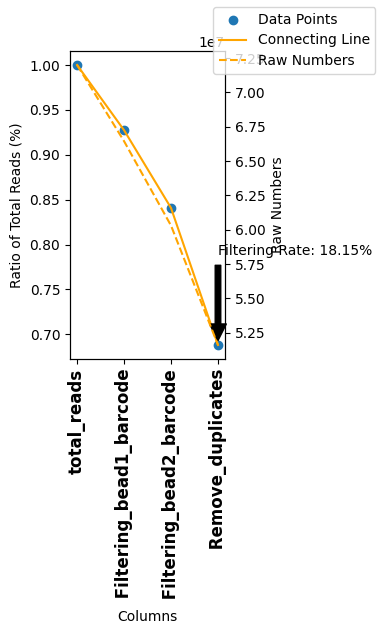

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df_read_numb = pd.read_csv("/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2/report/read_num_spatial_barcode/read_number.csv")

# # Filter the DataFrame to select only the third entry called "20240522_Min20_connection_S6"
# df_read_numb = df_read_numb[df_read_numb['sample'] == "20240928_Connection1_S3"]

# Ensure all data is numeric, excluding the sample column
df_read_numb_numeric = df_read_numb.drop(columns=['sample']).apply(pd.to_numeric, errors='coerce')

# Create a ratio DataFrame
df_read_numb_ratio = df_read_numb_numeric.copy()
for i in range(df_read_numb_ratio.shape[1]):
    if i != 0:
        df_read_numb_ratio.iloc[:, i] = np.divide(df_read_numb_numeric.iloc[:, i], df_read_numb_numeric.iloc[:, 0])
    else:
        df_read_numb_ratio.iloc[:, i] = 1

# Calculate the average of each column
column_avg = df_read_numb_ratio.mean()

# Calculate the filtering rate between points 5 and 6 (Adjusting for actual columns if necessary)
filtering_rate = 100 * (1 - column_avg.iloc[3] / column_avg.iloc[2])

# Create the plot
fig, ax1 = plt.subplots(figsize=(2, 4))  # Change figsize to desired width and height

# Scatter and line plot for percentage
ax1.scatter(column_avg.index, column_avg.values, label='Data Points')
ax1.plot(column_avg.index, column_avg.values, linestyle='-', color='orange', label='Connecting Line')
ax1.set_xlabel('Columns')
ax1.set_ylabel('Ratio of Total Reads (%)')
ax1.set_xticklabels(column_avg.index, rotation=90, fontsize='large', fontweight='bold')

# Add filtering rate annotation
ax1.annotate(f'Filtering Rate: {filtering_rate:.2f}%', xy=(3, column_avg.iloc[3]), xytext=(3, column_avg.iloc[3] + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Secondary y-axis for raw numbers
ax2 = ax1.twinx()
ax2.plot(df_read_numb_numeric.columns, df_read_numb_numeric.mean(), linestyle='--', color='orange', label='Raw Numbers')
ax2.set_ylabel('Raw Numbers')

# Add legend
fig.legend(loc='upper right')

# Save the plot as a PDF with modifiable text
plt.savefig("Readsfiltrationrate.pdf", format='pdf', bbox_inches='tight')

plt.show()


# downstream analysis

In [1]:
#Scanpy analyze 
import numpy as np
import pandas as pd
import scanpy as sc

#sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_header()
#sc.settings.set_figure_params(dpi=80, facecolor='white')

adata = sc.read('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data/Adata/adata_full.h5ad')  # replace 'yourfile.h5ad' with your filename
print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 55744 × 29912
    obs: 'total_UMI_count', 'not_aligned_UMI_count', 'not_aligned_ratio', 'Exon_count', 'Exon_ratio', 'UMI_count'
    var: 'Gene_type', 'Gene_name'


,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count
Cell_name,,,,,,
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA,340,12.0,0.035294,321,0.944118,328.0
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT,4619,146.0,0.031609,4408,0.954319,4473.0
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC,1903,84.0,0.044141,1787,0.939044,1819.0
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC,689,25.0,0.036284,654,0.949202,664.0
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT,7569,334.0,0.044127,7125,0.941340,7235.0


In [ ]:
adata.obs.head()

In [84]:
adata.var.head()

,Gene_type,Gene_name,Mouse_gene
Gene_name,,,
Gnai3,protein_coding,Gnai3,True
Cdc45,protein_coding,Cdc45,True
H19,lincRNA,H19,True
Scml2,protein_coding,Scml2,True
Apoh,protein_coding,Apoh,True


In [6]:
adata.X.shape  # (细胞数 × 基因数)

# 查看前5个细胞 × 前5个基因
import pandas as pd

# 提取并转为可读形式
df_expr = pd.DataFrame(
    adata.X[:5, :5].toarray() if hasattr(adata.X, "toarray") else adata.X[:5, :5],
    index=adata.obs_names[:5],
    columns=adata.var_names[:5]
)
print(df_expr)

Gene_id                                             ENSG00000000460.12  \
Cell_name                                                                
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA                   0   
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT                   0   
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC                   0   
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC                   0   
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT                   0   

Gene_id                                             ENSG00000001084.6  \
Cell_name                                                               
20240928_CDNA1.ACACCGTA-AACAACCG-AAGGATCC-AGCGTCTA                  0   
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT                  0   
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC                  0   
20240928_CDNA1.ACACCGTA-AACCAGGT-AACCTCTC-TACGGCTC                  0   
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-G

In [2]:
sc.pp.filter_cells(adata, min_counts= 300)

In [3]:
adata = adata[(adata.obs['total_UMI_count'] > 1000), :]

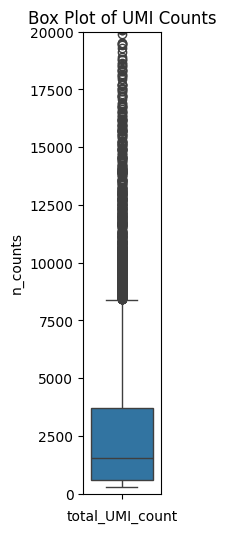

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Extract UMI counts
umi_gene = adata.obs['total_UMI_count']  # or the specific key where UMI counts are stored

plt.figure(figsize=(1, 6))
sns.boxplot(data=umi_counts)
plt.xlabel('total_UMI_count')
plt.title('Box Plot of UMI Counts')

# Set the maximum y value
plt.ylim(0, 20000)  # Replace 20000 with your desired maximum y value

# Save the figure as a PDF
plt.savefig('UMI_counts_plot.pdf', bbox_inches='tight')  # Ensure the plot fits within the PDF bounds

plt.show()

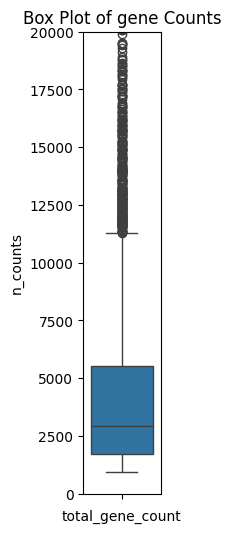

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Extract UMI counts
umi_gene_counts = adata.obs['n_counts']  # or the specific key where UMI counts are stored

plt.figure(figsize=(1, 6))
sns.boxplot(data=umi_gene_counts)
plt.xlabel('total_gene_count')
plt.title('Box Plot of gene Counts')

# Set the maximum y value
plt.ylim(0, 20000)  # Replace 20000 with your desired maximum y value

# Save the figure as a PDF
plt.savefig('gene_counts_plot.pdf', bbox_inches='tight')  # Ensure the plot fits within the PDF bounds

plt.show()

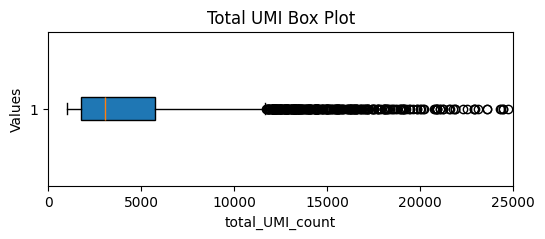

In [102]:
#自己尝试的代码：
import matplotlib.pyplot as plt
import numpy as np

# 创建箱型图
plt.figure(figsize=(6, 2))
plt.boxplot(adata.obs['total_UMI_count'], vert=False, patch_artist=True, notch=False)

# 添加标题和标签
plt.title('Total UMI Box Plot')
plt.xlabel('total_UMI_count')
plt.ylabel('Values')

plt.xlim(0, 25000)
plt.show()




In [4]:
def extract_sample(cell_name):
    samples = ["20240928_CDNA1", "20240928_CDNA2"]
    for sample in samples:
        if sample in cell_name:
            return sample
    return None  # If no sample match is found (optional)

# Create the new column based on the index of adata.obs
adata.obs['sample_source'] = adata.obs.index.to_series().apply(extract_sample)

/tmp/ipykernel_7371/1450167336.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample_source'] = adata.obs.index.to_series().apply(extract_sample)


In [5]:
adata.obs['extracted_ID'] = adata.obs.index.to_series().str.split('.').str[-1].apply(lambda x: x.replace('-', ''))
extracted_id_data = adata.obs['extracted_ID']

In [6]:
adata.var['Mouse_gene'] = adata.var.index.str[:4] == 'ENSM'
adata = adata[:, adata.var['Mouse_gene'] == True]
#Create column in obs with summed genes 
adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
adata.var.head().transpose()
adata.var.index = adata.var['Gene_name'].astype(str)
adata.var_names_make_unique()

/tmp/ipykernel_7371/3620107224.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)


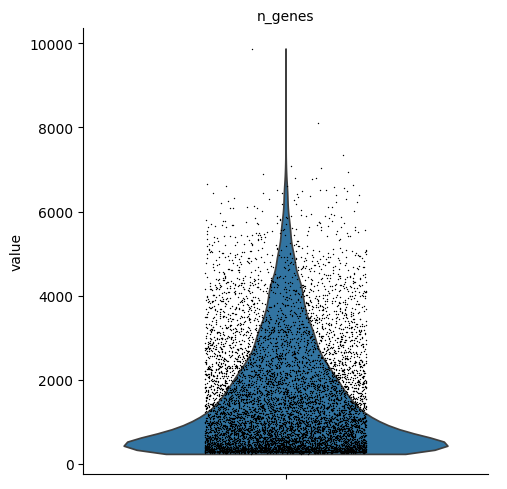

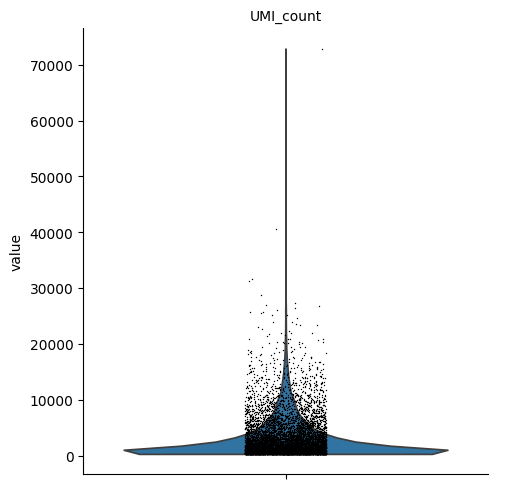

In [13]:
import scanpy as sc
import matplotlib.pyplot as plt

# 绘制 n_genes 的 violin 图，并旋转 x 轴标签
sc.pl.violin(adata, ['n_genes'], jitter=0.2, multi_panel=True)
plt.show()

# 绘制 UMI_count 的 violin 图，并旋转 x 轴标签
sc.pl.violin(adata, ['UMI_count'], jitter=0.1, multi_panel=True)
plt.show()


In [82]:
help(sc.pl.violin)

Help on function violin in module scanpy.plotting._anndata:

violin(adata: 'AnnData', keys: 'str | Sequence[str]', groupby: 'str | None' = None, *, log: 'bool' = False, use_raw: 'bool | None' = None, stripplot: 'bool' = True, jitter: 'float | bool' = True, size: 'int' = 1, layer: 'str | None' = None, density_norm: 'DensityNorm' = 'width', order: 'Sequence[str] | None' = None, multi_panel: 'bool | None' = None, xlabel: 'str' = '', ylabel: 'str | Sequence[str] | None' = None, rotation: 'float | None' = None, show: 'bool | None' = None, save: 'bool | str | None' = None, ax: 'Axes | None' = None, scale: 'DensityNorm | Empty' = _empty, **kwds) -> 'Axes | FacetGrid | None'
    Violin plot.

    Wraps :func:`seaborn.violinplot` for :class:`~anndata.AnnData`.

    Parameters
    ----------
    adata
        Annotated data matrix.
    keys
        Keys for accessing variables of `.var_names` or fields of `.obs`.
    groupby
        The key of the observation grouping to consider.
    log
      

In [7]:
# Get the number of cells per unique sample_source
cells_per_sample_source = adata.obs['sample_source'].value_counts()

print(cells_per_sample_source)

sample_source
20240928_CDNA1    5363
20240928_CDNA2      10
Name: count, dtype: int64


In [104]:
# Calculate total UMI count for each cell
adata.obs['total_UMI_count'] = adata.X.sum(axis=1)

# Calculate median total UMI count for each unique sample_source
median_total_UMI_count = adata.obs.groupby('sample_source')['total_UMI_count'].median()

print(median_total_UMI_count)

/tmp/ipykernel_15879/2832607858.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['total_UMI_count'] = adata.X.sum(axis=1)
/tmp/ipykernel_15879/2832607858.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_total_UMI_count = adata.obs.groupby('sample_source')['total_UMI_count'].median()


sample_source
20240928_CDNA1    2937.0
20240928_CDNA2    1118.5
Name: total_UMI_count, dtype: float64


In [105]:

# Calculate median total UMI count for each unique sample_source
median_total_UMI_count = adata.obs.groupby('sample_source')['n_genes'].median()

print(median_total_UMI_count)

sample_source
20240928_CDNA1    1876.0
20240928_CDNA2     843.5
Name: n_genes, dtype: float64


/tmp/ipykernel_15879/4256816730.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_total_UMI_count = adata.obs.groupby('sample_source')['n_genes'].median()


In [18]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


/tmp/ipykernel_12499/2470312292.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'


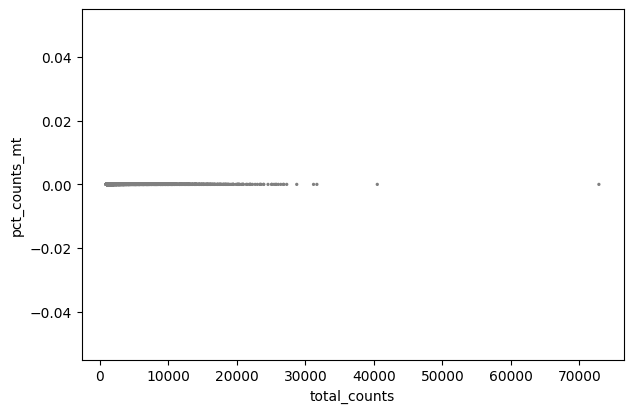

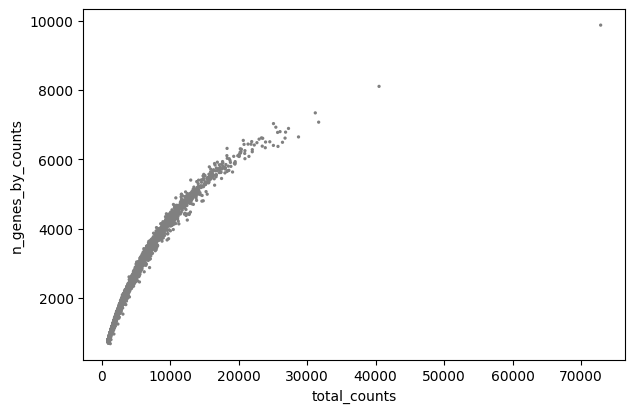

In [19]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [8]:
#normalize
adata=adata[adata.obs['sample_source'] == '20240928_CDNA1', :]
sc.pp.normalize_total(adata, target_sum=1e4)

/rugpfs/fs0/cao_lab/store/cwang04/packages/miniconda/envs/IRIS3/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:216: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


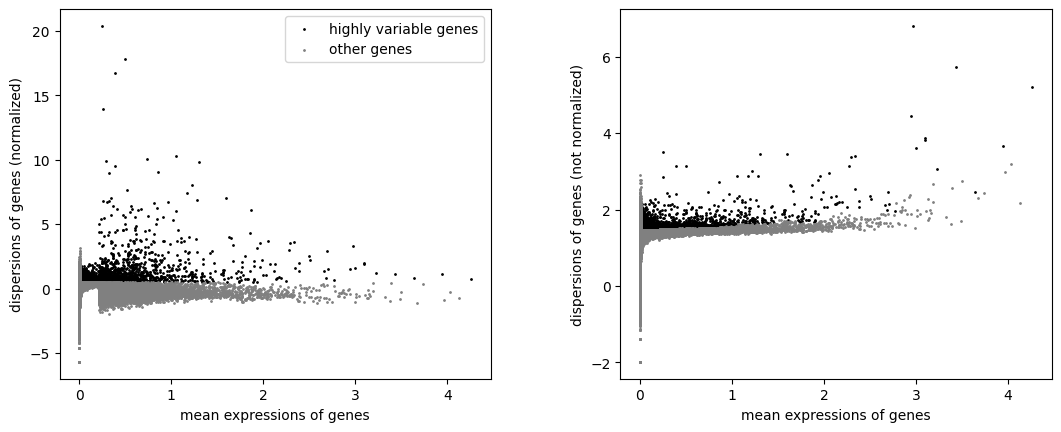

In [9]:
#find highly variable genes
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=5, min_disp=0.5)
sc.pl.highly_variable_genes(adata)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]

In [22]:
adata

View of AnnData object with n_obs × n_vars = 5363 × 4108
    obs: 'total_UMI_count', 'not_aligned_UMI_count', 'not_aligned_ratio', 'Exon_count', 'Exon_ratio', 'UMI_count', 'n_counts', 'sample_source', 'extracted_ID', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'Gene_type', 'Gene_name', 'Mouse_gene', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [10]:

sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.tl.pca(adata)
sc.pp.scale(adata, max_value=10)

sc.pl.pca(adata, color='Malat1')
sc.pl.pca_variance_ratio(adata, log=True)


/rugpfs/fs0/cao_lab/store/cwang04/packages/miniconda/envs/IRIS3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


KeyError: "None of [Index(['total_counts', 'pct_counts_mt'], dtype='object')] are in the [columns]"

In [ ]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=25)
sc.tl.umap(adata, min_dist=0, spread=3)
sc.tl.leiden(adata, resolution = 1.3)
sc.pl.umap(adata, color=['leiden'])
sc.pl.umap(adata, color=['Hpca'])

In [ ]:
sc.pl.umap(adata, color=['Ttr'])

/rugpfs/fs0/cao_lab/store/cwang04/packages/miniconda/envs/IRIS3/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:408: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


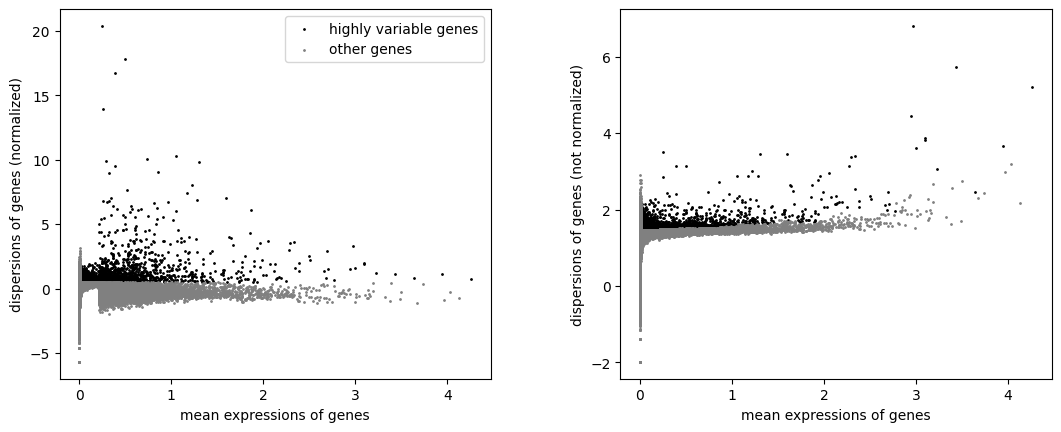

/rugpfs/fs0/cao_lab/store/cwang04/packages/miniconda/envs/IRIS3/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


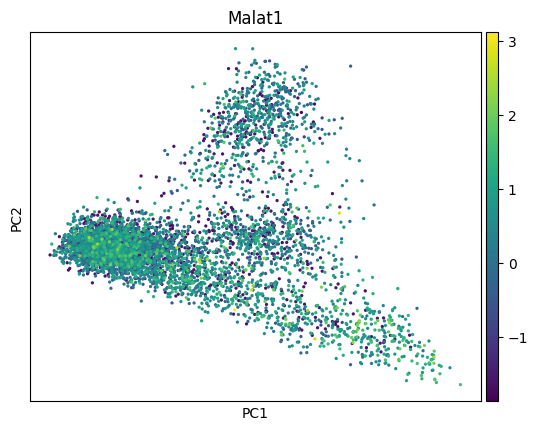

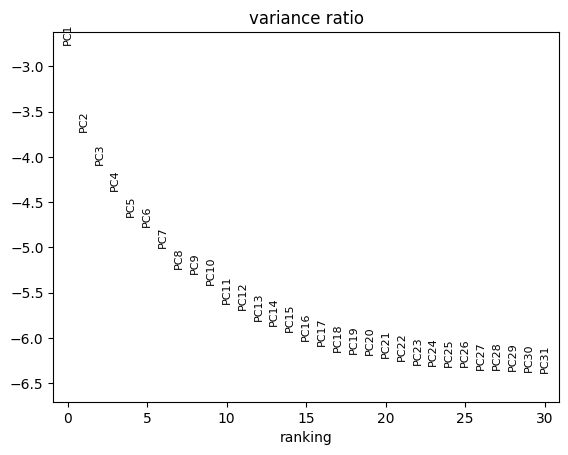

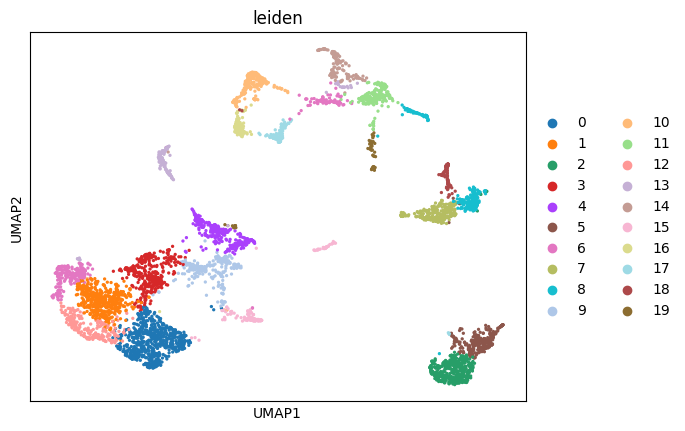

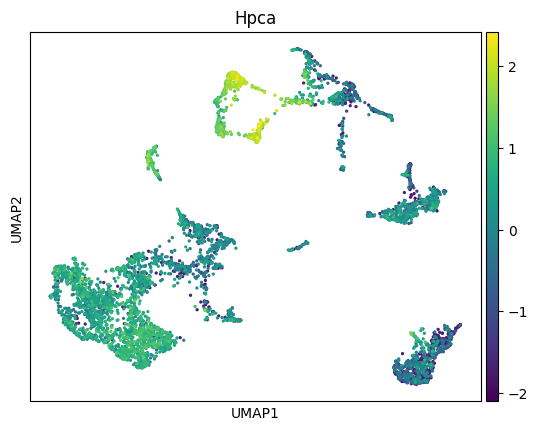

In [157]:
#自己尝试的代码

#adatapart = adata[adata.obs['sample_source'] == '20240928_CDNA1', :]


sc.pp.log1p(adatapart)
sc.pp.highly_variable_genes(adatapart, min_mean=0.0125, max_mean=5, min_disp=0.5)
sc.pl.highly_variable_genes(adatapart)

adata.raw = adatapart
adatapart = adatapart[:, adatapart.var.highly_variable]
sc.pp.regress_out(adatapart, ['total_counts', 'pct_counts_mt'])
sc.tl.pca(adatapart)
sc.pp.scale(adatapart, max_value=10)

sc.pl.pca(adatapart, color='Malat1')
sc.pl.pca_variance_ratio(adatapart, log=True)
sc.pp.neighbors(adatapart, n_neighbors=20, n_pcs=30)
sc.tl.umap(adatapart, min_dist=0, spread=3)
sc.tl.leiden(adatapart, resolution = 1.3)
sc.pl.umap(adatapart, color=['leiden'])
sc.pl.umap(adatapart, color=['Hpca'])



In [143]:
adata.obs.head()

,total_UMI_count,not_aligned_UMI_count,not_aligned_ratio,Exon_count,Exon_ratio,UMI_count,sample_source,extracted_ID,n_genes
Cell_name,,,,,,,,,
20240928_CDNA1.ACACCGTA-AACAACCG-GCGTTATG-AACCGCTT,4619,146.0,0.031609,4408,0.954319,4473.0,20240928_CDNA1,ACACCGTAAACAACCGGCGTTATGAACCGCTT,2505
20240928_CDNA1.ACACCGTA-AACACGAC-CTAAGCTC-ACGGCTAC,1903,84.0,0.044141,1787,0.939044,1819.0,20240928_CDNA1,ACACCGTAAACACGACCTAAGCTCACGGCTAC,1275
20240928_CDNA1.ACACCGTA-AACCTCTC-AACGGAAG-GCTCTGAT,7569,334.0,0.044127,7125,0.941340,7235.0,20240928_CDNA1,ACACCGTAAACCTCTCAACGGAAGGCTCTGAT,3445
20240928_CDNA1.ACACCGTA-AACCTCTC-GGCAATCT-AGCGTTAC,2081,104.0,0.049976,1945,0.934647,1977.0,20240928_CDNA1,ACACCGTAAACCTCTCGGCAATCTAGCGTTAC,1399
20240928_CDNA1.ACACCGTA-AACGGAAG-ACGTCAAC-GACGTTAC,2871,91.0,0.031696,2727,0.949843,2780.0,20240928_CDNA1,ACACCGTAAACGGAAGACGTCAACGACGTTAC,1672


In [158]:
# Get the number of cells per unique sample_source
cells_per_sample_source = adatapart.obs['sample_source'].value_counts()

print(cells_per_sample_source)

sample_source
20240928_CDNA1    5363
Name: count, dtype: int64


# Spatial information

In [3]:
#FO1_2
import pandas as pd

# File path
file_path = "/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2/Spatial_barcode_rmdup/20240928_Connection1_S3.spatial.csv.gz"

# Read the file
Filter = pd.read_csv(file_path, compression='gzip')

#Display the first few rows of the dataframe
print(Filter.head())

      ACACCGTAAGGTCCTAATGCCACAGGATCGAT  AACGGGGT  \
0   GTTCCTTCACCGCCTTAACCTCATCTGCTGACAT    GCAGGG   
1   GTCAAGGTGATCGAACCAAGCTTACCCTAACTCG    AGAGCG   
2     TCGAACCAGCGTTATGACAGCACTCATCTGGT  TTCTTCCG   
3   GTCCAGTTACCCGATGTACAAGGTGACTCTAACG    AACCCT   
4  AGTACTTCGGTCGACTCTTATTGGCTGGTCCGTTA     AATAG   

    GTGGTCTACAAGGTCCTAAATGCAGCGCTAACCCTGCA  
0     ACCTAGCAAGGAACGTCTATGGAGGCTAATCGACTG  
1     CAAGACCTAGCTTACCAGGTAGAGGCTAGATCAGCA  
2    TTGAGGATGAGGTAGAGCGTAGGTTGCTACGCTTACA  
3  AGTTGTGTGCTAGCACATGCAGAACACGCTATGAGCTCA  
4    TAGGAACGTGTACACCAACCTGTTGGCTAACCGCTAT  


In [ ]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data2/Spatial_barcode_rmdup/

In [4]:
Filter.columns = ["Bead1_seq", "UMI", "Bead2_seq"]

# Verify the column names have been changed
print(Filter.columns)


Index(['Bead1_seq', 'UMI', 'Bead2_seq'], dtype='object')


In [5]:
import pandas as pd

def bead1_bead2_interaction(input_df):
    # Rename columns
    inside_df = input_df.copy()
    inside_df.columns = ["Bead1_seq", "UMI", "Bead2_seq"]

    # Group by Bead1_seq and Bead2_seq, then count unique UMI values
    n_umi_per_interaction_table = inside_df.groupby(['Bead1_seq', 'Bead2_seq']).size().reset_index(name='n_umi')

    # Group by Bead1_seq and count unique UMI values
    n_umi_per_bead1_table = n_umi_per_interaction_table.groupby('Bead1_seq').size().reset_index(name='n_umi')

    return {'n_umi_per_interaction': n_umi_per_interaction_table,
            'n_umi_per_bead1': n_umi_per_bead1_table}

# Sample usage:
# Assuming you have your data in df
# result = bead1_bead2_interaction(df)
# print(result['n_umi_per_interaction'])
# print(result['n_umi_per_bead1'])

In [6]:
output_list_patterns_Filter = bead1_bead2_interaction(Filter)


In [7]:
import numpy as np

# Assuming output_list_patterns_Filter is a dictionary and n_umi_per_interaction is a key pointing to a DataFrame
output_list_patterns_Filter['n_umi_per_interaction']['log_transformed'] = np.log10(output_list_patterns_Filter['n_umi_per_interaction']['n_umi'])


In [8]:
# Assuming output_list_patterns_Filter is a dictionary and n_umi_per_interaction is a key pointing to a DataFrame
filtered_df_filter = output_list_patterns_Filter['n_umi_per_interaction'][output_list_patterns_Filter['n_umi_per_interaction']['log_transformed'] >= .8]


In [9]:
n_umi_range = filtered_df_filter['n_umi'].agg(['min', 'max'])

print("Range of n_umi column:")
print(f"Min: {n_umi_range['min']}")

print(f"Max: {n_umi_range['max']}")


Range of n_umi column:
Min: 7
Max: 1289


In [10]:
import pandas as pd
import numpy as np

# Extract unique values
unique_bead1_seq = filtered_df_filter['Bead1_seq'].unique()
unique_bead2_seq = filtered_df_filter['Bead2_seq'].unique()


# Get the number of unique values
num_bead1_seq = len(unique_bead1_seq)
num_bead2_seq = len(unique_bead2_seq)

# Create a DataFrame initialized with zeros
matrix_data_filter = pd.DataFrame(0, index=unique_bead1_seq, columns=unique_bead2_seq)

# Fill the DataFrame with counts from the original DataFrame
for _, row in filtered_df_filter.iterrows():
    matrix_data_filter.at[row['Bead1_seq'], row['Bead2_seq']] = row['n_umi']


In [11]:
matrix_data_filter.to_csv('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1.csv')

In [1]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/

total 79G
drwxr-xr-x 2 cwang04 4.0K Apr  8 14:29 ./
drwxr-xr-x 3 cwang04 4.0K Apr  7 15:45 ../
-rw-r--r-- 1 cwang04  79G Apr  9 03:51 20240928_CDNA1.csv


In [ ]:
#canberra

#Load UMAP coordinates
import pandas as pd

# Define the path to the CSV file
file_path = "/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
matrix_data_filter

In [ ]:
np.savetxt('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1_connection_matrix.txt', matrix_data_filter)

In [ ]:
# Log1p transformation
matrix_data_log1p = np.log1p(matrix_data_filter)

# Standardize the data (optional but often recommended)
scaler = StandardScaler()
matrix_data_standardized = scaler.fit_transform(matrix_data_log1p)

# Perform PCA on the standardized and log-transformed data
pca = PCA(n_components=2000)
pca.fit(matrix_data_standardized)

# Plot the explained variance as a function of the number of components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Elbow Plot for PCA')
plt.show()

In [ ]:
# Perform PCA on the standardized and log-transformed data

# Log1p transformation
matrix_data_log1p = np.log1p(matrix_data_filter)

# Standardize the data (optional but often recommended)
scaler = StandardScaler()
matrix_data_standardized = scaler.fit_transform(matrix_data_log1p)

pca = PCA(n_components=600)
matrix_data_pca = pca.fit_transform(matrix_data_standardized)


In [ ]:
import numpy as np
import umap
from sklearn.preprocessing import normalize

# Set random seed for reproducibility
SEED = 42  # Set this to your desired seed value


# Create and fit the UMAP transformer
mapper = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2
    ,
    metric='euclidean',
    random_state=SEED,
    n_epochs=500,
    verbose=True, spread=.6
)
coords = mapper.fit_transform(matrix_data_pca)

In [ ]:
umap_df = pd.DataFrame(coords, columns=['UMAP1','UMAP2'], index=matrix_data_filter.index)


In [ ]:
import matplotlib.pyplot as plt

def plot_umap(embedding, title='UMAP Embedding', s=1, figsize=(10, 10)):
    """
    Plots UMAP embeddings.
    
    Parameters:
    - embedding: UMAP embeddings (typically from mapper.fit_transform)
    - title: Title of the plot
    - s: Size of each point
    - figsize: Size of the figure
    """
    plt.figure(figsize=figsize)
    plt.scatter(embedding[:, 0], embedding[:, 1], s=s, cmap='Spectral')
    plt.gca().set_aspect('equal', 'datalim')
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title(title)
    plt.show()

# To plot your coords
plot_umap(coords, title="UMAP projection with specified parameters")


In [ ]:
#FO1_2
# Specify your desired file path and name
file_path = "/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1_connection.csv"

# Save the DataFrame to a CSV file
umap_df.to_csv(file_path)

# Optionally print a message to indicate the process is done
print(f"Data saved to {file_path}")


# spatial information with AA data

In [1]:
#FO1_2
import pandas as pd

# File path
file_path = "/rugpfs/fs0/cao_lab/scratch/aabdul/projects/AA_20231221_BeadArraySeq_42/Intermediate_data_connections/Spatial_barcode_rmdup/20231221_FO2_2_connection.spatial.csv.gz"
# Read the file
Filter = pd.read_csv(file_path, compression='gzip')

#Display the first few rows of the dataframe
print(Filter.head())

  AGTGAACTGCTGATCGGTAGACTTGAGCAACCTAG  CCTGAACG  \
0   TCTTAGTGGCGTGCATAAAGGATCCTACGTCGT  GAGTGCGA   
1  GTCAAGGTGATCGCATTCAGGTCCTAGACTAGTC  GGCTGGCC   
2   TATGTTGGCGCGTTATGAGCACATGGAGTTGCA  TGGTTTTA   
3    CGTGCATAACAGCACTAACAACCGGATTGAGC  TGAGGCGG   
4   TCGGAATTGTTCTGAGGAGCATGGATACGTCGT  TTGGGTAG   

     TCGGAATTGGAGAGAGTTTCTGAGGGCTACAACCTAG  
0    TGACCATACGCAAGCAAGTACACCAGCTAATCGTGAC  
1  AGTTTGTTCCGGCGTTATGTGTGTGCTGCTAGTGCAAGT  
2  AGTGTCAGAACTTGTTCCGACGCTTGTGCTACATCTGGT  
3  AGTGGCTCAATCTCACAGTAACACGACGCTATCGAGACT  
4   GTCGTAGGTTCGTAGGTTATACGTGCGCTATCCGAGTT  


In [2]:
Filter.columns = ["Bead1_seq", "UMI", "Bead2_seq"]

# Verify the column names have been changed
print(Filter.columns)

Index(['Bead1_seq', 'UMI', 'Bead2_seq'], dtype='object')


In [3]:
import pandas as pd

def bead1_bead2_interaction(input_df):
    # Rename columns
    inside_df = input_df.copy()
    inside_df.columns = ["Bead1_seq", "UMI", "Bead2_seq"]

    # Group by Bead1_seq and Bead2_seq, then count unique UMI values
    n_umi_per_interaction_table = inside_df.groupby(['Bead1_seq', 'Bead2_seq']).size().reset_index(name='n_umi')

    # Group by Bead1_seq and count unique UMI values
    n_umi_per_bead1_table = n_umi_per_interaction_table.groupby('Bead1_seq').size().reset_index(name='n_umi')

    return {'n_umi_per_interaction': n_umi_per_interaction_table,
            'n_umi_per_bead1': n_umi_per_bead1_table}


In [4]:
output_list_patterns_Filter = bead1_bead2_interaction(Filter)


In [5]:
import numpy as np

# Assuming output_list_patterns_Filter is a dictionary and n_umi_per_interaction is a key pointing to a DataFrame
output_list_patterns_Filter['n_umi_per_interaction']['log_transformed'] = np.log10(output_list_patterns_Filter['n_umi_per_interaction']['n_umi'])


In [6]:
# Assuming output_list_patterns_Filter is a dictionary and n_umi_per_interaction is a key pointing to a DataFrame
filtered_df_filter = output_list_patterns_Filter['n_umi_per_interaction'][output_list_patterns_Filter['n_umi_per_interaction']['log_transformed'] >= .8]


In [7]:
n_umi_range = filtered_df_filter['n_umi'].agg(['min', 'max'])

print("Range of n_umi column:")
print(f"Min: {n_umi_range['min']}")

print(f"Max: {n_umi_range['max']}")


Range of n_umi column:
Min: 7
Max: 26235


In [8]:
import pandas as pd
import numpy as np

# Extract unique values
unique_bead1_seq = filtered_df_filter['Bead1_seq'].unique()
unique_bead2_seq = filtered_df_filter['Bead2_seq'].unique()


# Get the number of unique values
num_bead1_seq = len(unique_bead1_seq)
num_bead2_seq = len(unique_bead2_seq)

# Create a DataFrame initialized with zeros
matrix_data_filter = pd.DataFrame(0, index=unique_bead1_seq, columns=unique_bead2_seq)

# Fill the DataFrame with counts from the original DataFrame
for _, row in filtered_df_filter.iterrows():
    matrix_data_filter.at[row['Bead1_seq'], row['Bead2_seq']] = row['n_umi']


In [9]:
matrix_data_filter.to_csv('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/AAspatial.csv')

In [11]:
import pandas as pd

# 读取 CSV（Bead1 是 index）
matrix = pd.read_csv('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/AAspatial.csv', index_col=0)

# 统计数量
num_bead1 = matrix.shape[0]  # 行数 → Bead1
num_bead2 = matrix.shape[1]  # 列数 → Bead2

print(f"Total Bead1 (rows): {num_bead1}")
print(f"Total Bead2 (columns): {num_bead2}")


Total Bead1 (rows): 12382
Total Bead2 (columns): 5514


In [ ]:
import pandas as pd

# 读取 CSV（Bead1 是 index）
matrix = pd.read_csv('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1.csv', index_col=0)

# 统计数量
num_bead1 = matrix.shape[0]  # 行数 → Bead1
num_bead2 = matrix.shape[1]  # 列数 → Bead2

print(f"Total Bead1 (rows): {num_bead1}")
print(f"Total Bead2 (columns): {num_bead2}")

In [10]:
ll -alh /rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/

total 79G
drwxr-xr-x 2 cwang04 4.0K Apr 14 20:52 ./
drwxr-xr-x 3 cwang04 4.0K Apr  7 15:45 ../
-rw-r--r-- 1 cwang04  79G Apr  9 03:51 20240928_CDNA1.csv
-rw-r--r-- 1 cwang04 132M Apr 14 20:52 AAspatial.csv


In [ ]:
#canberra

#Load UMAP coordinates
import pandas as pd

# Define the path to the CSV file
file_path = "/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
matrix_data_filter

In [ ]:
np.savetxt('/rugpfs/fs0/cao_lab/store/cwang04/projects/IRIseq-pipeline/Intermediate_data_connections/UMAP/20240928_CDNA1_connection_matrix.txt', matrix_data_filter)

# whole spatial part

In [ ]:
adata = sc.read('/rugpfs/fs0/cao_lab/scratch/aabdul/projects/AA_20231221_BeadArraySeq_42/AA_20231221_BeadArraySeq_42_FO2_5_nova/Adata/adata_full.h5ad')  # replace 'yourfile.h5ad' with your filename
def extract_sample(cell_name):
    samples = ["Sample_01", "Sample_02", "Sample_03", "Sample_05"]
    for sample in samples:
        if sample in cell_name:
            return sample
    return None  # If no sample match is found (optional)

# Create the new column based on the index of adata.obs
adata.obs['sample_source'] = adata.obs.index.to_series().apply(extract_sample)
adata.obs['extracted_ID'] = adata.obs.index.to_series().str.split('.').str[-1].apply(lambda x: x.replace('-', ''))
adata.var['Mouse_gene'] = adata.var.index.str[:4] == 'ENSM'
adata = adata[:, adata.var['Mouse_gene'] == True]
#Create column in obs with summed genes 
adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
adata.var.head().transpose()
adata.var.index = adata.var['Gene_name'].astype(str)
adata.var_names_make_unique()


sc.pp.filter_cells(adata, min_counts= 300)
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.pct_counts_mt < 5, :]
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.tl.pca(adata)
sc.pp.scale(adata, max_value=10)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=12)
sc.tl.umap(adata, min_dist=0)
sc.tl.leiden(adata, resolution = 1)



In [ ]:
#canberra

#Load UMAP coordinates
import pandas as pd

# Define the path to the CSV file
file_path = "/rugpfs/fs0/cao_lab/scratch/aabdul/projects/AA_20231221_BeadArraySeq_42/Intermediate_data_connections/UMAP/FO2_5_connection.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())

# Backup the 'cell_name' index to a temporary column
adata.obs['cell_name_temp'] = adata.obs.index

# Perform the merge
merged = adata.obs.merge(df, left_on="extracted_ID", right_on="Unnamed: 0", how="left", suffixes=('_adata', '_df'))

# Restore the 'cell_name' index from the temporary column
merged.index = merged['cell_name_temp']
adata.obs = merged.drop(columns=['cell_name_temp', 'Unnamed: 0'])  # Removing unwanted columns

print("Columns before removal:")
print(adata.obs.head())

# Remove 'UMAP1' and 'UMAP2' columns
columns_to_remove = ['UMAP1','UMAP2','UMAP1_df','UMAP2_df']
adata.obs = adata.obs.drop(columns=columns_to_remove, errors='ignore')

# Check the columns after removal
print("\nColumns after removal:")
print(adata.obs.head())

import matplotlib.pyplot as plt
import scanpy as sc

# Get the colors used by scanpy for categorical data
colors = sc.pl.palettes.default_102

# Create a dictionary mapping each leiden cluster to a color
cluster_colors = {cluster: colors[i] for i, cluster in enumerate(adata.obs['leiden'].cat.categories)}
import matplotlib.pyplot as plt
import scanpy as sc

# Extracting colors used by Scanpy for categorical data
colors = sc.pl.palettes.default_102

# Create a dictionary mapping each leiden cluster to a color
cluster_colors = {cluster: colors[i] for i, cluster in enumerate(adata.obs['leiden'].cat.categories)}

# Plotting
plt.figure(figsize=(10,8))

# Map leiden clusters to their colors
colors_mapped = adata.obs['leiden'].map(cluster_colors).tolist()

plt.scatter(adata.obs['UMAP1'], adata.obs['UMAP2'], c=colors_mapped, s=20, alpha=0.7)

# Legend creation
labels = list(adata.obs['leiden'].cat.categories)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_colors[cat], markersize=10) 
           for cat in labels]
plt.legend(handles=handles, labels=labels, loc='upper right', fontsize='small', title='Leiden Clusters')

# Plot title and labels
plt.title('UMAP Plot colored by Leiden Clusters')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)

plt.show()
